## procesamiento de los datos para machine learning
Aplicar las tecnicas principales de procesamiento de datos para preparar un dataset antes del entrenimiento 

## parte 1. compresion del problema 
Trabajaremos con el DATASED de Titanic, para construir un modelo que sea capaz de precidir si una persona sobrevive o no

In [48]:
##importamos las librerias 
import pandas as pd
import numpy as np

##Libreria de machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

##librerias para graficar
import seaborn as sns
import matplotlib.pyplot as plt

##libreria de kaggle
import kagglehub

In [49]:
#Dscargamos el Dataser de la pagina kaggle
path = kagglehub.dataset_download("yasserh/titanic-dataset")
path

'C:\\Users\\yonat\\.cache\\kagglehub\\datasets\\yasserh\\titanic-dataset\\versions\\1'

In [50]:
dfTitanic = pd.read_csv(path + "/Titanic-Dataset.csv")#Creamos el dataframe

In [51]:
dfTitanic.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [52]:
dfTitanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [53]:
dfTitanic["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [54]:
dfTitanic.groupby(
    "Sex"
)["Survived"].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [55]:
dfTitanic.groupby(
    "Pclass"
)["Survived"].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

##parte 3 correccion e hipotesis


In [56]:
variables_numericas = [
    "Survived",
    "Pclass",
    "Parch",
    "Fare"
]

In [57]:
corr = dfTitanic[variables_numericas].corr()
corr

,Survived,Pclass,Parch,Fare
Survived,1.000000,-0.338481,0.081629,0.257307
Pclass,-0.338481,1.000000,0.018443,-0.549500
Parch,0.081629,0.018443,1.000000,0.216225
Fare,0.257307,-0.549500,0.216225,1.000000


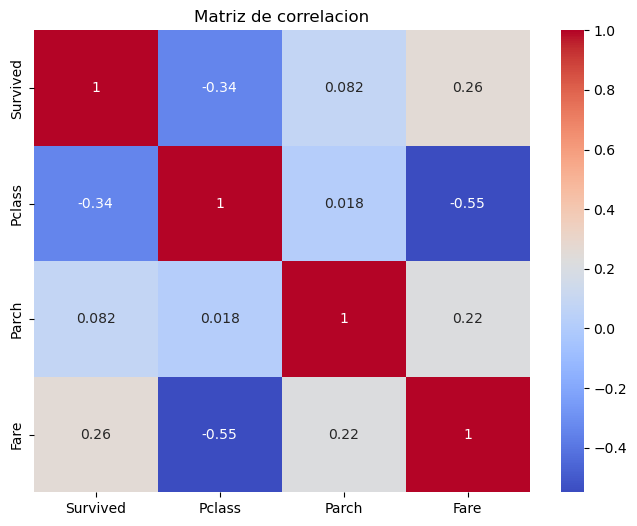

In [58]:
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)
plt.title("Matriz de correlacion")
plt.show()

## Parte 4. Variables predictoras.

x --> Aquellas variables que nos ayudan a predecir
y --> Variavle objetivo

In [59]:
columnas= [
    "Pclass",
    "Sex",
    "Age",
    "Fare",
    "Embarked"
]

In [60]:
x = dfTitanic[columnas]
y = dfTitanic["Survived"]

## Parte 5. Limpieza de los datos

Realizaremos la imputacion de los datos, donde existan valores nulos.

In [61]:
x.isnull().sum()

Pclass        0
Sex           0
Age         177
Fare          0
Embarked      2
dtype: int64

In [62]:
x = x.copy()
x["Age"] = x["Age"].fillna(
x["Age"].median()

)

In [63]:
x["Embarked"] = x["Embarked"].fillna(
x["Embarked"].mode() [0]

)

In [64]:
x.isnull().sum()

Pclass      0
Sex         0
Age         0
Fare        0
Embarked    0
dtype: int64

## Parte 6: Normalizamos los datos categoricos (texto)

Los algoritmos de ML no entienden texto.

In [65]:
x.head(2)

,Pclass,Sex,Age,Fare,Embarked
0,3,male,22.0,7.2500,S
1,1,female,38.0,71.2833,C


In [66]:
#One Hot Encoding
x= pd.get_dummies(
x,
columns=[
"Sex",
"Embarked"
],
drop_first=True

)

In [67]:
x.head(2)

,Pclass,Age,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,7.2500,True,False,True
1,1,38.0,71.2833,False,False,False


## Parte 7. División de los datos

No debemos entrenar y evaluar utilizando los mismos datos.

80% para entrenar

20% para evaluar

In [68]:

x_train, x_test, y_train, y_test = train_test_split(
x,
y,
test_size=0.20,
random_state=42
)

In [72]:
print("Entrenamiento: ", x_train.shape)

Entrenamiento:  (712, 6)


In [74]:
print("Prueba X: ", x_test. shape)

Prueba X:  (179, 6)


In [75]:
print("Entrenamiento Y: ", y_train. shape)

Entrenamiento Y:  (712,)


In [76]:
print("Prueba Y: ", y_test. shape)

Prueba Y:  (179,)
